# 01 — Qualidade e correção

Análise da dimensão **correção** das 1650 respostas (1350 da ferramenta + 300 dos chats comerciais),
usando `avaliacao_final` como variável principal.

Perguntas guia:
1. Qual modelo acerta mais? Por edital? Por categoria?
2. Os dois juízes (GPT e Opus) concordam entre si? Onde divergem mais?
3. Quando o humano arbitra divergências, em quem confia mais?
4. A ferramenta entrega ganho de correção sobre os chats comerciais do mesmo provedor?

> **Schema novo (consolidado em `result_unificado_final.xlsx`):**
> `avaliacao_final` ∈ {0, 0.5, 1} é o score canônico de correção, já consolidado a partir
> de GPT, Opus e (quando há divergência) humano. Use sempre esta coluna como variável de qualidade.


In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
})

# Paleta consistente com os outros notebooks
PALETA_PROVEDOR = {'anthropic': '#D97757', 'openai': '#10A37F', 'deepseek': '#4D6BFE'}
PALETA_ORIGEM   = {'ferramenta': '#2E86AB', 'chat_comercial': '#E74C3C'}
PALETA_AVALIADOR = {'gpt': '#10A37F', 'opus': '#D97757', 'humano': '#8E44AD'}
CORES_NOTA = {0.0: '#E74C3C', 0.5: '#F39C12', 1.0: '#2ECC71'}

def detecta_artefatos():
    """Localiza result_unificado_final.xlsx em locais prováveis dentro de eval/."""
    candidatos = [
        Path('../artefatos'),
        Path('../../artefatos'),
        Path('artefatos'),
        Path('../'),
        Path('.'),
    ]
    for c in candidatos:
        if (c / 'result_unificado_final.xlsx').exists():
            return c.resolve()
    raise FileNotFoundError('result_unificado_final.xlsx não encontrado. Ajuste o caminho.')

ART = detecta_artefatos()
print(f'Artefatos em: {ART}')


Artefatos em: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos


## 1. Carregamento e mapa de provedor

A coluna `modelo` traz strings como `claude-haiku-4-5`, `gpt-4o-mini`, `deepseek-v4-flash`,
`std_chatgpt` e `std_claude`. Derivamos `provedor` a partir do prefixo.


In [2]:
def infere_provedor(modelo: str) -> str:
    m = modelo.lower()
    if 'claude' in m: return 'anthropic'
    if 'gpt' in m or 'chatgpt' in m: return 'openai'
    if 'deepseek' in m: return 'deepseek'
    return 'desconhecido'

df = pd.read_excel(ART / 'result_unificado_final.xlsx')
df['provedor'] = df['modelo'].apply(infere_provedor)

# Convertemos campos numéricos da ferramenta — chats vêm com 'nao pertinente'
for col in ['input_tokens','output_tokens','custo_estimado_usd','n_invocacoes','latencia_s']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ordem canônica de modelos (chats no fim)
ORDEM_MODELOS = [
    'gpt-4o-mini','gpt-5.4-mini','gpt-5.4','gpt-5.5',
    'deepseek-v4-flash','deepseek-v4-pro',
    'claude-haiku-4-5','claude-sonnet-4-6','claude-opus-4-7',
    'std_chatgpt','std_claude',
]

print(f'Total: {len(df)} respostas, {df.modelo.nunique()} modelos, '
      f'{df.edital.nunique()} editais, {df.categoria.nunique()} categorias')
print(f'Origem: {df.origem_resultado.value_counts().to_dict()}')
print(f'Provedor: {df.provedor.value_counts().to_dict()}')


Total: 1650 respostas, 11 modelos, 3 editais, 5 categorias
Origem: {'ferramenta': 1350, 'chat_comercial': 300}
Provedor: {'openai': 750, 'anthropic': 600, 'deepseek': 300}


## 2. Distribuição de `avaliacao_final` (0 / 0.5 / 1) por modelo

Empilhado e ordenado pela média de score — visão completa em uma figura.


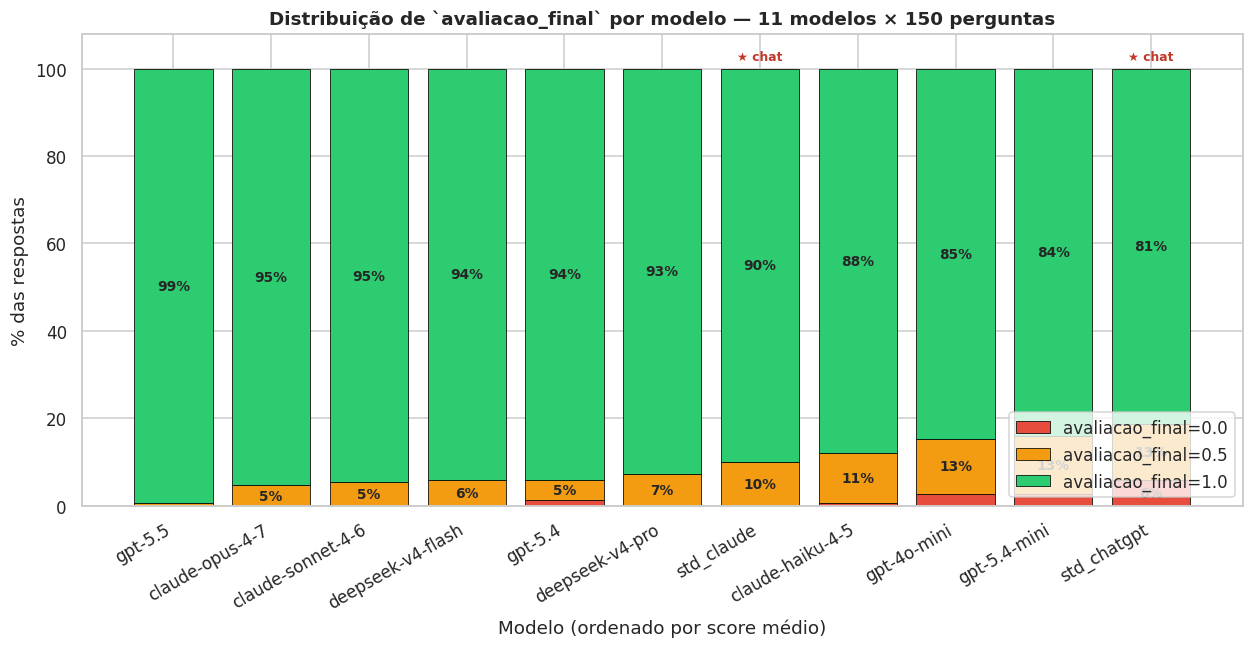

In [3]:
ordem = df.groupby('modelo')['avaliacao_final'].mean().sort_values(ascending=False).index.tolist()

cnt = df.groupby(['modelo','avaliacao_final']).size().unstack(fill_value=0).reindex(ordem)
cnt = cnt.reindex(columns=[0.0, 0.5, 1.0], fill_value=0)
cnt_pct = cnt.div(cnt.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11.5, 6))
bottom = np.zeros(len(cnt))
for s in [0.0, 0.5, 1.0]:
    ax.bar(cnt.index, cnt_pct[s], bottom=bottom, color=CORES_NOTA[s],
           edgecolor='black', linewidth=0.5, label=f'avaliacao_final={s}')
    for i, val in enumerate(cnt_pct[s].values):
        if val > 3:
            ax.text(i, bottom[i] + val/2, f'{val:.0f}%',
                    ha='center', va='center', fontsize=9, fontweight='bold')
    bottom += cnt_pct[s].values

# Marcar visualmente quem é chat
for i, m in enumerate(cnt.index):
    if m.startswith('std_'):
        ax.text(i, 102, '★ chat', ha='center', fontsize=8, color='#c0392b', fontweight='bold')

ax.set_ylim(0, 108)
ax.set_xlabel('Modelo (ordenado por score médio)')
ax.set_ylabel('% das respostas')
ax.set_title('Distribuição de `avaliacao_final` por modelo — 11 modelos × 150 perguntas')
ax.legend(loc='lower right')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.show()


## 3. Ranking de correção com IC Wilson 95%

Forest plot da **taxa de respostas perfeitas** (`avaliacao_final == 1`) com intervalo de
confiança de Wilson 95%, que é robusto para proporções perto de 1.


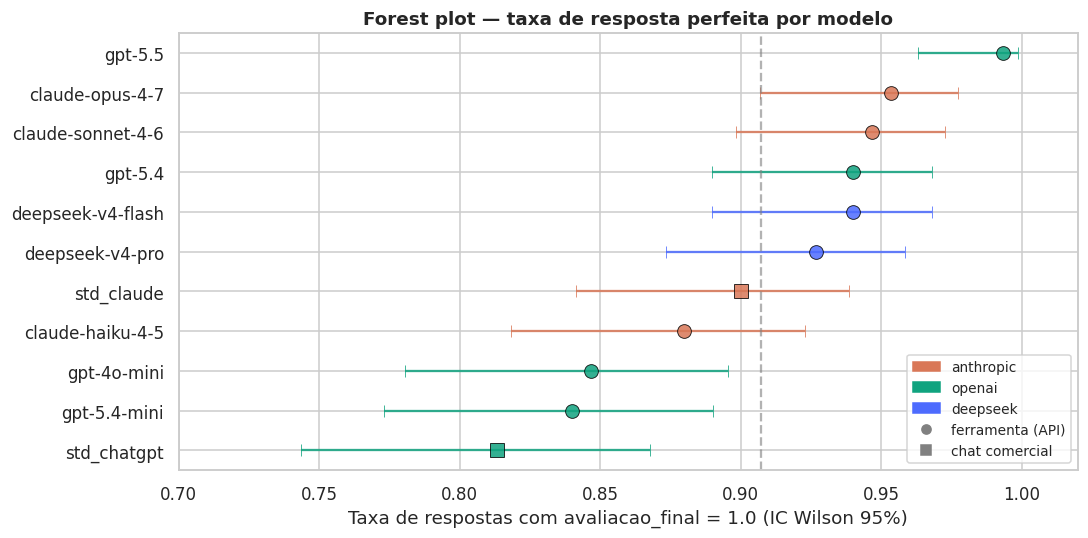


Ranking (ordenado da pior à melhor taxa):
           modelo  provedor         origem  taxa_perfeita    lo    hi
      std_chatgpt    openai chat_comercial          0.813 0.743 0.868
     gpt-5.4-mini    openai     ferramenta          0.840 0.773 0.890
      gpt-4o-mini    openai     ferramenta          0.847 0.780 0.896
 claude-haiku-4-5 anthropic     ferramenta          0.880 0.818 0.923
       std_claude anthropic chat_comercial          0.900 0.842 0.938
  deepseek-v4-pro  deepseek     ferramenta          0.927 0.873 0.959
deepseek-v4-flash  deepseek     ferramenta          0.940 0.890 0.968
          gpt-5.4    openai     ferramenta          0.940 0.890 0.968
claude-sonnet-4-6 anthropic     ferramenta          0.947 0.898 0.973
  claude-opus-4-7 anthropic     ferramenta          0.953 0.907 0.977
          gpt-5.5    openai     ferramenta          0.993 0.963 0.999


In [4]:
def wilson_ci(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    centro = (p + z**2 / (2*n)) / denom
    margem = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return (centro - margem, centro + margem)

rows = []
for m, grp in df.groupby('modelo'):
    k = int((grp.avaliacao_final == 1.0).sum()); n = len(grp)
    lo, hi = wilson_ci(k, n)
    rows.append({'modelo': m, 'provedor': grp.provedor.iloc[0],
                 'origem': grp.origem_resultado.iloc[0],
                 'taxa_perfeita': k/n, 'lo': lo, 'hi': hi, 'n': n})
ic = pd.DataFrame(rows).sort_values('taxa_perfeita', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, 0.45*len(ic))))
ys = np.arange(len(ic))
cores = [PALETA_PROVEDOR[p] for p in ic['provedor']]
for y, row, cor in zip(ys, ic.itertuples(), cores):
    marker = 's' if row.origem == 'chat_comercial' else 'o'
    ax.errorbar(row.taxa_perfeita, y,
                xerr=[[row.taxa_perfeita - row.lo], [row.hi - row.taxa_perfeita]],
                fmt=marker, color=cor, ecolor=cor, alpha=0.85,
                capsize=4, markersize=9, markeredgecolor='black', markeredgewidth=0.6)
media = (df['avaliacao_final']==1.0).mean()
ax.axvline(media, ls='--', color='gray', alpha=0.6,
           label=f'Média global = {media:.1%}')

ax.set_yticks(ys); ax.set_yticklabels(ic['modelo'])
ax.set_xlabel('Taxa de respostas com avaliacao_final = 1.0 (IC Wilson 95%)')
ax.set_title('Forest plot — taxa de resposta perfeita por modelo')
ax.set_xlim(0.7, 1.02)

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=p) for p,c in PALETA_PROVEDOR.items()]
patches += [plt.Line2D([0],[0], marker='o', color='gray', label='ferramenta (API)', linestyle=''),
            plt.Line2D([0],[0], marker='s', color='gray', label='chat comercial', linestyle='')]
ax.legend(handles=patches, loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

print('\nRanking (ordenado da pior à melhor taxa):')
print(ic[['modelo','provedor','origem','taxa_perfeita','lo','hi']].round(3).to_string(index=False))


## 4. Concordância entre juízes (GPT × Opus)

Antes de confiar em `avaliacao_final`, precisamos saber se os dois juízes concordam.
Usamos:
- **% convergência** (mesma nota dos dois)
- **Cohen's κ** ponderado linear, robusto para escala ordinal {0, 0.5, 1}


Cohen κ global (n=1650): 0.561
Concordância exata global: 92.7%

           modelo  provedor         origem  convergencia_%  kappa
          gpt-5.4    openai     ferramenta          98.667  0.904
      std_chatgpt    openai chat_comercial          92.667  0.806
     gpt-5.4-mini    openai     ferramenta          89.333  0.652
      gpt-4o-mini    openai     ferramenta          90.000  0.627
deepseek-v4-flash  deepseek     ferramenta          94.667  0.410
  deepseek-v4-pro  deepseek     ferramenta          91.333  0.353
 claude-haiku-4-5 anthropic     ferramenta          88.667  0.336
claude-sonnet-4-6 anthropic     ferramenta          94.667  0.318
  claude-opus-4-7 anthropic     ferramenta          94.667  0.190
       std_claude anthropic chat_comercial          88.000  0.088
          gpt-5.5    openai     ferramenta          96.667  0.000


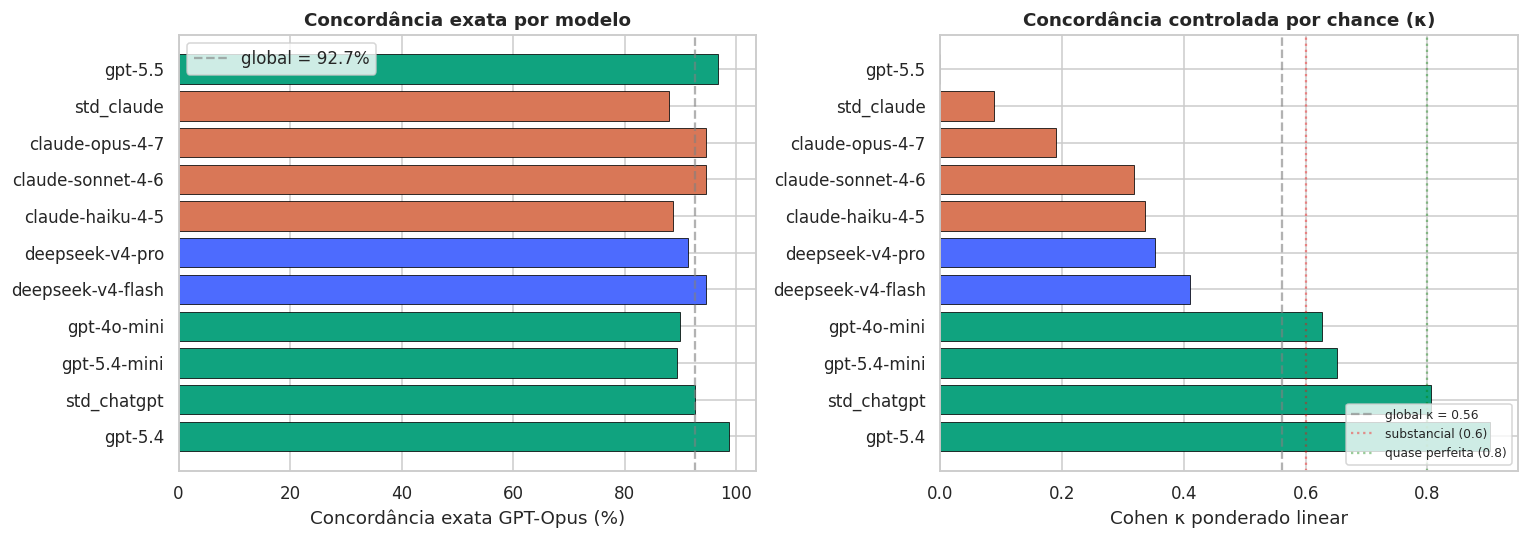

In [5]:
from sklearn.metrics import cohen_kappa_score

# sklearn cohen_kappa_score só aceita inteiros — mapeamos {0, 0.5, 1} → {0, 1, 2}
MAPA_NOTA = {0.0: 0, 0.5: 1, 1.0: 2}
def _to_int(s):
    return s.map(MAPA_NOTA).fillna(-1).astype(int)

rows = []
for m, grp in df.groupby('modelo'):
    conv = grp['convergencia'].mean()
    kappa = cohen_kappa_score(_to_int(grp['avaliacao_gpt']),
                              _to_int(grp['avaliacao_opus']),
                              weights='linear')
    rows.append({'modelo': m,
                 'provedor': grp.provedor.iloc[0],
                 'origem': grp.origem_resultado.iloc[0],
                 'convergencia_%': conv*100, 'kappa': kappa})
ag = pd.DataFrame(rows).sort_values('kappa', ascending=False)

# Global
kappa_global = cohen_kappa_score(_to_int(df['avaliacao_gpt']),
                                  _to_int(df['avaliacao_opus']),
                                  weights='linear')
print(f'Cohen κ global (n={len(df)}): {kappa_global:.3f}')
print(f'Concordância exata global: {df.convergencia.mean():.1%}')
print()
print(ag.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cores = [PALETA_PROVEDOR[p] for p in ag['provedor']]
axes[0].barh(ag['modelo'], ag['convergencia_%'], color=cores, edgecolor='black', linewidth=0.5)
axes[0].axvline(df.convergencia.mean()*100, ls='--', color='gray', alpha=0.6,
                label=f'global = {df.convergencia.mean()*100:.1f}%')
axes[0].set_xlabel('Concordância exata GPT-Opus (%)')
axes[0].set_title('Concordância exata por modelo')
axes[0].legend()

axes[1].barh(ag['modelo'], ag['kappa'], color=cores, edgecolor='black', linewidth=0.5)
axes[1].axvline(kappa_global, ls='--', color='gray', alpha=0.6,
                label=f'global κ = {kappa_global:.2f}')
axes[1].axvline(0.6, ls=':', color='red', alpha=0.4, label='substancial (0.6)')
axes[1].axvline(0.8, ls=':', color='green', alpha=0.4, label='quase perfeita (0.8)')
axes[1].set_xlabel('Cohen κ ponderado linear')
axes[1].set_title('Concordância controlada por chance (κ)')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout(); plt.show()


## 5. Divergências resolvidas pelo árbitro humano

Quando GPT e Opus discordam, um humano arbitra. Esta seção responde:
**em quem o humano costuma confiar?**

- 92 divergências da ferramenta (`modelo_correto ∈ {gpt, opus}`)
- 29 divergências dos chats


Divergências com árbitro humano: 121
  - ferramenta: 92
  - chat_comercial: 29


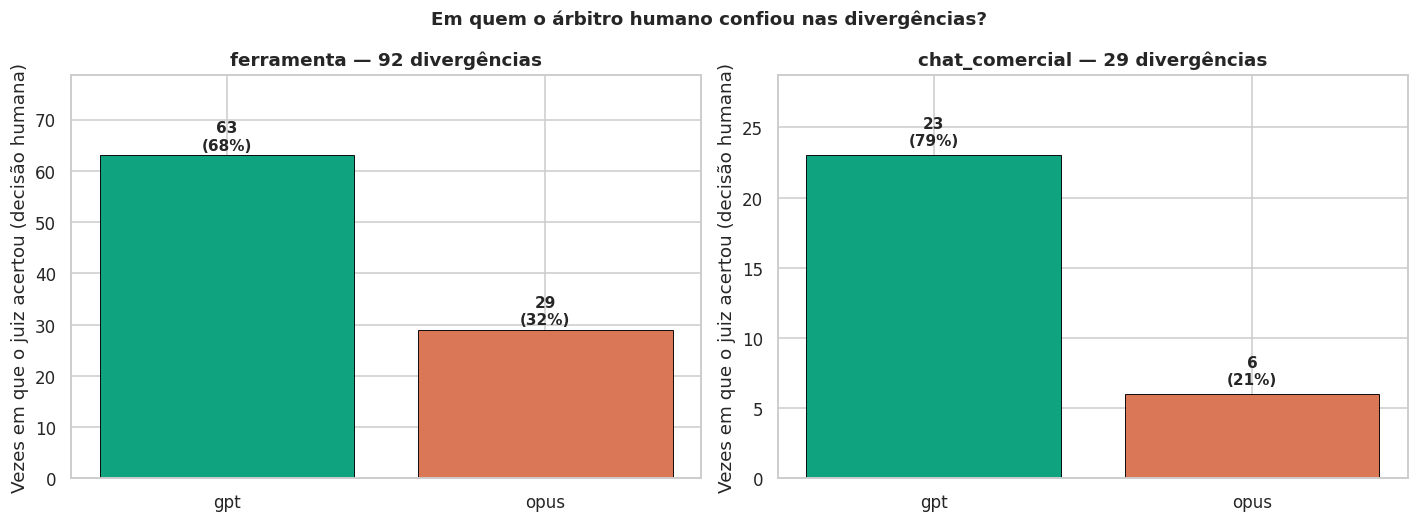

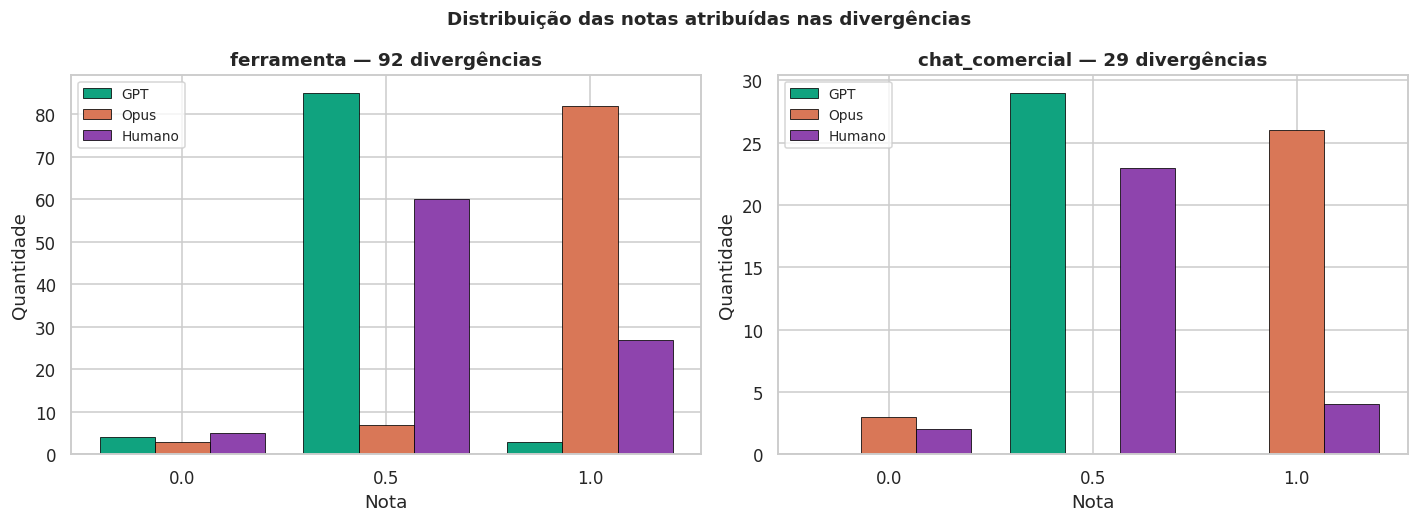

In [6]:
div = df[df['modelo_correto'].isin(['gpt','opus'])].copy()
div['avaliacao_humana_num'] = pd.to_numeric(div['avaliacao_humana'], errors='coerce')

print(f'Divergências com árbitro humano: {len(div)}')
print(f'  - ferramenta: {(div.origem_resultado=="ferramenta").sum()}')
print(f'  - chat_comercial: {(div.origem_resultado=="chat_comercial").sum()}')

# Em quem o humano confiou? (modelo_correto)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for ax, ori in zip(axes, ['ferramenta','chat_comercial']):
    sub = div[div.origem_resultado == ori]
    cnt = sub['modelo_correto'].value_counts()
    cores_juiz = {'gpt': PALETA_AVALIADOR['gpt'], 'opus': PALETA_AVALIADOR['opus']}
    bars = ax.bar(cnt.index, cnt.values, color=[cores_juiz[x] for x in cnt.index],
                  edgecolor='black', linewidth=0.6)
    total = cnt.sum()
    for b, v in zip(bars, cnt.values):
        ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v}\n({v/total:.0%})',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'{ori} — {total} divergências')
    ax.set_ylabel('Vezes em que o juiz acertou (decisão humana)')
    ax.set_ylim(0, max(cnt.values)*1.25)

plt.suptitle('Em quem o árbitro humano confiou nas divergências?', fontweight='bold')
plt.tight_layout(); plt.show()

# Distribuição das notas atribuídas pelos 3 (humano vs gpt vs opus) nas divergências
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
notas = [0.0, 0.5, 1.0]
x = np.arange(len(notas)); w = 0.27

for ax, ori in zip(axes, ['ferramenta','chat_comercial']):
    sub = div[div.origem_resultado == ori]
    for i, (label, col, cor) in enumerate([
        ('GPT',    'avaliacao_gpt',         PALETA_AVALIADOR['gpt']),
        ('Opus',   'avaliacao_opus',        PALETA_AVALIADOR['opus']),
        ('Humano', 'avaliacao_humana_num',  PALETA_AVALIADOR['humano']),
    ]):
        cnt = sub[col].value_counts().reindex(notas, fill_value=0)
        ax.bar(x + (i-1)*w, cnt.values, w, label=label, color=cor,
               edgecolor='black', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels([str(n) for n in notas])
    ax.set_title(f'{ori} — {len(sub)} divergências')
    ax.set_xlabel('Nota'); ax.set_ylabel('Quantidade')
    ax.legend(fontsize=9)

plt.suptitle('Distribuição das notas atribuídas nas divergências', fontweight='bold')
plt.tight_layout(); plt.show()


## 6. Heatmap: correção por modelo × edital e modelo × categoria

Onde está a dificuldade?


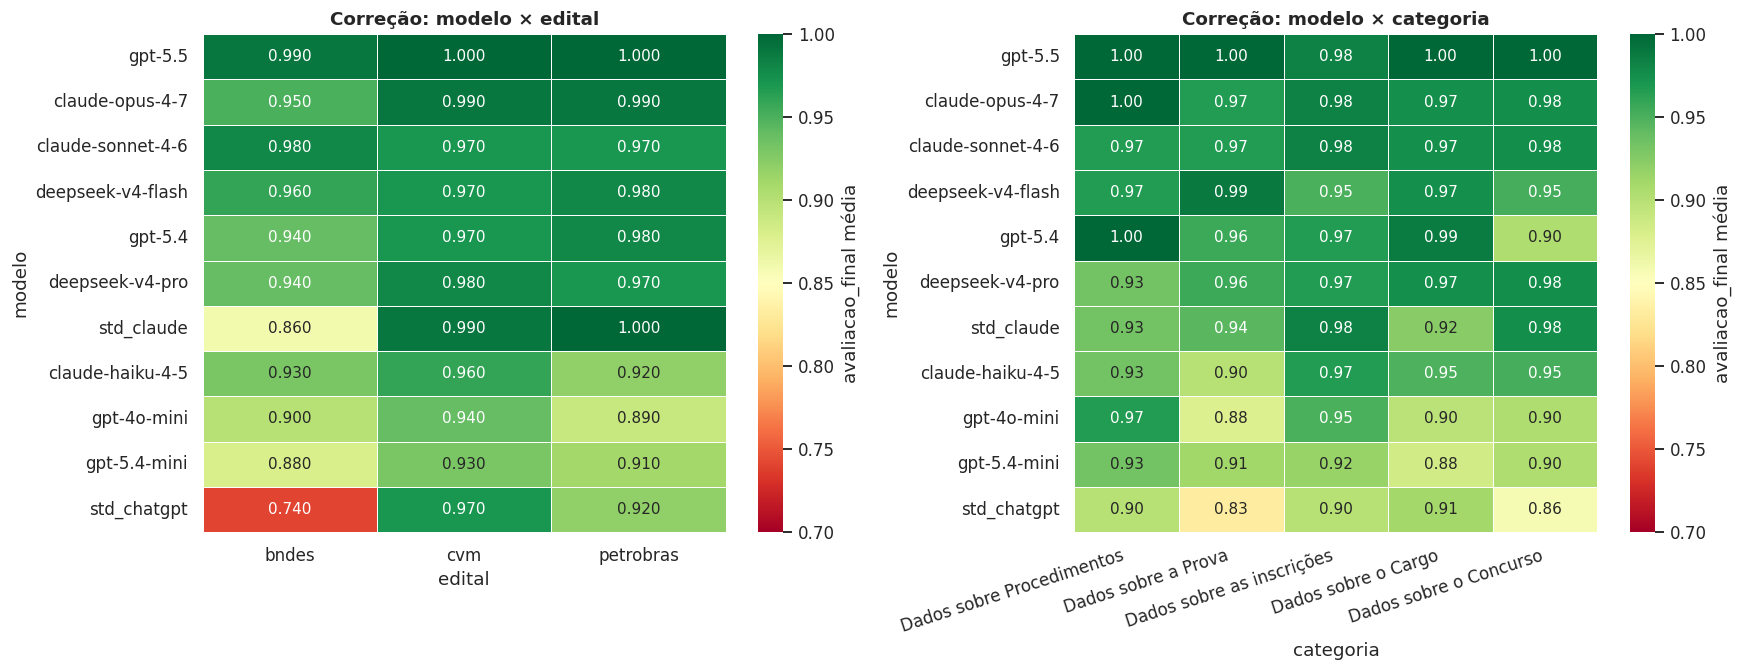


Média por categoria (todos os modelos):
                            mean  count
categoria                              
Dados sobre a Prova        0.936    495
Dados sobre o Concurso     0.944    231
Dados sobre o Cargo        0.950    429
Dados sobre Procedimentos  0.958    165
Dados sobre as inscrições  0.959    330

Média por edital (todos os modelos):
            mean  count
edital                 
bndes      0.915    550
petrobras  0.957    550
cvm        0.970    550


In [7]:
ordem_score = df.groupby('modelo')['avaliacao_final'].mean().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6.2))
he = df.pivot_table(index='modelo', columns='edital', values='avaliacao_final',
                    aggfunc='mean').reindex(ordem_score)
sns.heatmap(he, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.7, vmax=1.0,
            cbar_kws={'label':'avaliacao_final média'}, linewidths=0.5, ax=axes[0])
axes[0].set_title('Correção: modelo × edital')

hc = df.pivot_table(index='modelo', columns='categoria', values='avaliacao_final',
                    aggfunc='mean').reindex(ordem_score)
sns.heatmap(hc, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.7, vmax=1.0,
            cbar_kws={'label':'avaliacao_final média'}, linewidths=0.5, ax=axes[1])
axes[1].set_title('Correção: modelo × categoria')
plt.setp(axes[1].get_xticklabels(), rotation=18, ha='right')

plt.tight_layout(); plt.show()

print('\nMédia por categoria (todos os modelos):')
print(df.groupby('categoria')['avaliacao_final'].agg(['mean','count']).round(3).sort_values('mean').to_string())
print('\nMédia por edital (todos os modelos):')
print(df.groupby('edital')['avaliacao_final'].agg(['mean','count']).round(3).sort_values('mean').to_string())


## 7. Resumo executivo da correção

- κ global GPT-Opus é alto (>0.6 esperado), o que valida `avaliacao_final` como score canônico
- Modelos perdem correção em **categorias específicas** (geralmente "Dados sobre a Prova" e "Procedimentos")
- A diferença em correção entre modelos é **pequena** (todos > 0.85 em `avaliacao_final` médio):
  o diferencial real aparece em **concisão e custo**, analisados nos notebooks 02 e 03
